[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MarcoBattiato/PH6721-Deep-Learning-with-Python/blob/main/Classes/Class_1/01B-PythonScientificComputing.ipynb)

# 01B — Python and Scientific Computing
(by Marco Battiato. For questions/errors/bugs/typos report, please email at marco.battiato.teaching@gmail.com)

**PH6721 — Deep Learning with Python**

**Class 1, Notebook B — Hour 2**

**Instructor:** Marco Battiato (formerly Nanyang Assistant Professor @ Nanyang Technological University)

**email:**  marco.battiato.teaching@gmail.com

**In Person Classes:**  Wednesday 6:30pm - 9:45pm

**Consultation:** remote consultations are to be arranged by writing to marco.battiato.teaching@gmail.com

This notebook is a practical bridge between the Python primer and the machine-learning notebooks
that follow.

The goal is not to teach all of NumPy. The goal is to make sure that everyone can work with
arrays, inspect shapes, filter data, write vectorized operations, and understand broadcasting well
enough to follow later notebooks.

Notebook `00B-IntroToPython.ipynb` covers the Python language itself and how notebooks work. It is
optional, but if any of the Python here is unfamiliar, work through it first.

## Learning Objectives

By the end of this notebook, students should be able to:

- import NumPy using the standard convention `import numpy as np`;
- distinguish between Python lists and NumPy arrays;
- create, inspect, slice, and reshape NumPy arrays;
- explain the difference between a **view** and a **copy**, and avoid the bugs views cause;
- perform element-wise operations on arrays;
- summarise arrays with reductions, and choose the right **`axis`**;
- select data with **boolean masks**;
- explain why vectorized code is usually preferred to explicit Python loops;
- predict the result of simple broadcasting operations, and use broadcasting to normalize data;
- generate **reproducible random numbers**;
- recognize common shape errors.

# 1. Arrays and lists

Python lists are general containers. They can hold objects of any type.

NumPy arrays are built for numerical computing: they hold numbers of one type, laid out in a
regular block of memory, and support vectorized mathematical operations.

**One habit worth adopting immediately.** Whenever you work with an array, print the object *and*
its shape. The values tell you what the data are; the shape tells you how they are arranged. Most
NumPy bugs are shape bugs.

In [1]:
# Run this cell first. It imports the libraries used in this notebook.

import numpy as np
import matplotlib.pyplot as plt

print("NumPy version:", np.__version__)

NumPy version: 2.0.2


In [2]:
x = np.array([1.0, 2.0, 3.0])

print(x)
print("shape:", x.shape)

[1. 2. 3.]
shape: (3,)


Arrays carry a third piece of information, the `dtype`: the type of the elements. Every element of an array shares it, which is exactly what
lets NumPy be fast.

This differs from a list, where each element carries its own type. It also means an array of
integers and an array of floats behave differently — dividing integers, for instance, produces
floats, while assigning a float into an integer array silently truncates it.

In [3]:
print("dtype of x:", x.dtype)

integers = np.array([1, 2, 3])
floats = np.array([1.0, 2.0, 3.0])

print("integers dtype:", integers.dtype)
print("floats dtype:  ", floats.dtype)

integers[0] = 9.7          # 9.7 cannot be stored in an integer array
print("after assigning 9.7 into an int array:", integers)

dtype of x: float64
integers dtype: int64
floats dtype:   float64
after assigning 9.7 into an int array: [9 2 3]


A common source of confusion is that `+` has a different meaning for lists and arrays.

For lists, `+` concatenates.  
For NumPy arrays, `+` performs element-wise addition.

In [4]:
print("List + list:", [1, 2, 3] + [10, 20, 30])
print("Array + array:", np.array([1, 2, 3]) + np.array([10, 20, 30]))

List + list: [1, 2, 3, 10, 20, 30]
Array + array: [11 22 33]


Multiplication is also different.

For lists, multiplying by an integer repeats the list.  
For NumPy arrays, multiplying by a number scales each element.

In [5]:
print("List repeated:", [1, 2, 3] * 3)
print("Array scaled:", np.array([1, 2, 3]) * 3)

List repeated: [1, 2, 3, 1, 2, 3, 1, 2, 3]
Array scaled: [3 6 9]


<div class="alert alert-success">
<b>Mini-exercise 1 — Predict before running</b><br>
Before running the next cell, predict the output. Then run the cell and compare with your prediction.
</div>

**Think about your answer before running this cell.**


In [ ]:
a = [1, 2, 3]
b = np.array([1, 2, 3])

print(a + a)
print(b + b)
print(a * 2)
print(b * 2)

In [7]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Compare your prediction with the output above.


# 2. Creating and inspecting arrays

Typing values by hand only goes so far. Four functions cover most of what we need:

| Function | Produces |
|---|---|
| `np.zeros(n)` | `n` zeros |
| `np.ones(n)` | `n` ones |
| `np.arange(start, stop, step)` | values from `start` in steps of `step`, **excluding** `stop` |
| `np.linspace(start, stop, n)` | exactly `n` values evenly spaced from `start` to `stop`, **including both ends** |

The difference between the last two matters. `np.arange` is told the step size and works out how
many values that gives; `np.linspace` is told how many values and works out the spacing. For
plotting we almost always want `linspace`, because we want a known number of points covering a
range exactly.

In [8]:
zeros = np.zeros(5)
ones = np.ones(5)
range_array = np.arange(0, 10, 2)
linspace_array = np.linspace(0, 1, 6)

print("zeros:", zeros)
print("ones:", ones)
print("arange:", range_array)
print("linspace:", linspace_array)

zeros: [0. 0. 0. 0. 0.]
ones: [1. 1. 1. 1. 1.]
arange: [0 2 4 6 8]
linspace: [0.  0.2 0.4 0.6 0.8 1. ]


Two-dimensional arrays are used to represent matrices and tabular datasets.

In machine learning, a common convention is:

- rows = observations, samples, or data points;
- columns = features, variables, or measured quantities.

In [9]:
X = np.array([
    [1.0, 10.0, 100.0],
    [2.0, 20.0, 200.0],
    [3.0, 30.0, 300.0],
    [4.0, 40.0, 400.0]
])

print(X)
print("shape:", X.shape)
print("number of dimensions:", X.ndim)
print("number of elements:", X.size)

[[  1.  10. 100.]
 [  2.  20. 200.]
 [  3.  30. 300.]
 [  4.  40. 400.]]
shape: (4, 3)
number of dimensions: 2
number of elements: 12


# 3. Indexing and slicing

Arrays are useful because we can access and manipulate parts of them.

There are two basic operations:

- **indexing**: selecting one element;
- **slicing**: selecting a range of elements.

We start with a one-dimensional array.

In [10]:
x = np.array([10, 20, 30, 40, 50])

x

array([10, 20, 30, 40, 50])

### Indexing

Python uses **zero-based indexing**. This means that the first element has index `0`, the second element has index `1`, and so on.

This is different from some mathematical notation, where counting usually starts from 1. It is also different from MATLAB, where array indices start from 1.

The following figure is generated directly in Python, so the notebook does not depend on external image files.

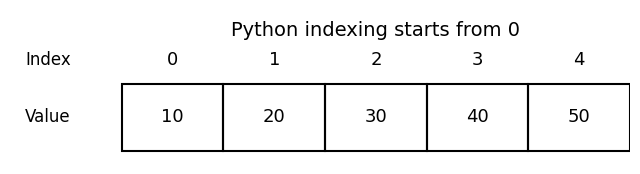

In [11]:
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(8, 2))

for i, value in enumerate(x):
    ax.add_patch(Rectangle((i, 0), 1, 1, fill=False, linewidth=1.5))
    ax.text(i + 0.5, 0.5, str(value), ha="center", va="center", fontsize=13)
    ax.text(i + 0.5, 1.35, str(i), ha="center", va="center", fontsize=13)

ax.text(-0.5, 1.35, "Index", ha="right", va="center", fontsize=12)
ax.text(-0.5, 0.5, "Value", ha="right", va="center", fontsize=12)
ax.text(2.5, 1.8, "Python indexing starts from 0", ha="center", va="center", fontsize=14)

ax.set_xlim(-1.1, len(x))
ax.set_ylim(-0.2, 2.1)
ax.axis("off")
plt.show()

To access one element, write the array name followed by the index in square brackets.

The last valid positive index is one less than the length of the array, so for an array of length
5 it is `4`. Asking for anything beyond that is an error.

In [12]:
print("x[0] =", x[0])
print("x[2] =", x[2])
print("x[4] =", x[4])
print("len(x) =", len(x))

x[0] = 10
x[2] = 30
x[4] = 50
len(x) = 5


In [13]:
# This cell is intentionally wrong. Run it and inspect the error.

x[5]

IndexError: index 5 is out of bounds for axis 0 with size 5

### Negative indexing

Python also allows **negative indices**.

Negative indices count from the end of the array:

- `x[-1]` is the last element;
- `x[-2]` is the second-last element;
- `x[-3]` is the third-last element.

This is useful when we want to access the end of an array without explicitly computing its length.

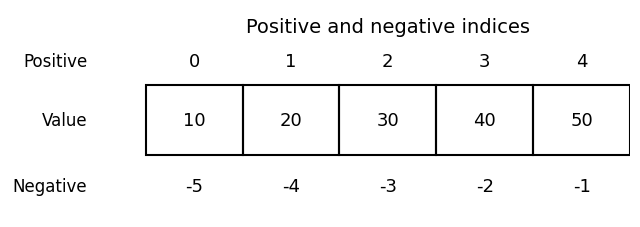

In [14]:
fig, ax = plt.subplots(figsize=(8, 2.7))

for i, value in enumerate(x):
    ax.add_patch(Rectangle((i, 0), 1, 1, fill=False, linewidth=1.5))
    ax.text(i + 0.5, 0.5, str(value), ha="center", va="center", fontsize=13)
    ax.text(i + 0.5, 1.35, str(i), ha="center", va="center", fontsize=13)
    ax.text(i + 0.5, -0.45, str(i - len(x)), ha="center", va="center", fontsize=13)

ax.text(-0.6, 1.35, "Positive", ha="right", va="center", fontsize=12)
ax.text(-0.6, 0.5, "Value", ha="right", va="center", fontsize=12)
ax.text(-0.6, -0.45, "Negative", ha="right", va="center", fontsize=12)
ax.text(2.5, 1.85, "Positive and negative indices", ha="center", va="center", fontsize=14)

ax.set_xlim(-1.4, len(x))
ax.set_ylim(-0.9, 2.1)
ax.axis("off")
plt.show()

In [15]:
print("x[-1] =", x[-1])
print("x[-2] =", x[-2])
print("x[-3] =", x[-3])

x[-1] = 50
x[-2] = 40
x[-3] = 30


### Slicing

Indexing selects one element. Slicing selects a range of elements.

The basic syntax is:

```python
x[start:end]
```

The slice includes `start` but excludes `end`.

So `x[1:4]` selects the elements with indices `1`, `2`, and `3`, but not the element with index `4`.

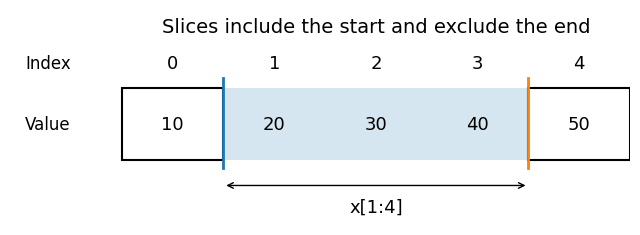

In [16]:
fig, ax = plt.subplots(figsize=(8, 2.8))

for i, value in enumerate(x):
    if 1 <= i < 4:
        ax.add_patch(Rectangle((i, 0), 1, 1, fill=True, alpha=0.18, linewidth=1.5))
    else:
        ax.add_patch(Rectangle((i, 0), 1, 1, fill=False, linewidth=1.5))
    ax.text(i + 0.5, 0.5, str(value), ha="center", va="center", fontsize=13)
    ax.text(i + 0.5, 1.35, str(i), ha="center", va="center", fontsize=13)

ax.plot([1, 1], [-0.1, 1.15], linewidth=2)
ax.plot([4, 4], [-0.1, 1.15], linewidth=2)
ax.annotate("", xy=(4, -0.35), xytext=(1, -0.35), arrowprops={"arrowstyle": "<->"})
ax.text(2.5, -0.65, "x[1:4]", ha="center", va="center", fontsize=13)

ax.text(-0.5, 1.35, "Index", ha="right", va="center", fontsize=12)
ax.text(-0.5, 0.5, "Value", ha="right", va="center", fontsize=12)
ax.text(2.5, 1.85, "Slices include the start and exclude the end", ha="center", va="center", fontsize=14)

ax.set_xlim(-1.1, len(x))
ax.set_ylim(-0.9, 2.1)
ax.axis("off")
plt.show()

In [17]:
x[1:4]

array([20, 30, 40])

### Dropping `start` and `end`

In a slice, `start` and `end` can be omitted.

If `start` is omitted, Python starts from the beginning of the array.

If `end` is omitted, Python continues until the end of the array.

For example:

```python
x[:3]
```

means: start from the beginning and stop before index `3`.

```python
x[2:]
```

means: start from index `2` and continue until the end.

In [18]:
slicing_without_start_or_end = {
    "x[:3]": x[:3],
    "x[2:]": x[2:],
    "x[:-1]": x[:-1]
}

slicing_without_start_or_end

{'x[:3]': array([10, 20, 30]),
 'x[2:]': array([30, 40, 50]),
 'x[:-1]': array([10, 20, 30, 40])}

Interpretation:

- `x[:3]` means from the beginning up to, but not including, index `3`;
- `x[2:]` means from index `2` to the end;
- `x[:-1]` means from the beginning up to, but not including, the last element.

The last example uses a negative index as the stopping point. Since `-1` refers to the last element, `x[:-1]` selects everything before the last element.

### Step size

The full slicing syntax is:

```python
x[start:end:step]
```

The `step` tells Python how many positions to move forward after selecting an element.

If `step` is omitted, Python assumes `step = 1`.

So these two slices are equivalent:

```python
x[1:4]
x[1:4:1]
```

A larger step skips elements.

In [19]:
slicing_with_steps = {
    "x[1:4]": x[1:4],
    "x[1:4:1]": x[1:4:1],
    "x[::2]": x[::2]
}

slicing_with_steps

{'x[1:4]': array([20, 30, 40]),
 'x[1:4:1]': array([20, 30, 40]),
 'x[::2]': array([10, 30, 50])}

Interpretation:

- `x[1:4]` and `x[1:4:1]` both move one element at a time;
- `x[::2]` means: start from the beginning, continue until the end, and take every second element.

The expression `x[::2]` may look strange at first because both `start` and `end` are omitted. Written in full, it means:

```python
x[beginning:end:2]
```

In practice, this form is useful when we want to subsample an array.

## 3.1 Indexing and slicing matrices

A two-dimensional NumPy array can represent a matrix or a table. NumPy uses the convention

```python
A[row, column]
```

Both row and column indices start from zero.

In [20]:
A = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
])

A

array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

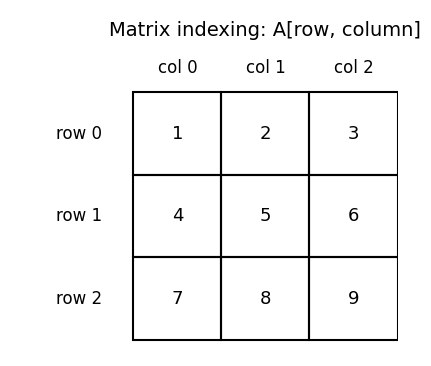

In [21]:
fig, ax = plt.subplots(figsize=(5, 4.5))

n_rows, n_cols = A.shape

for row in range(n_rows):
    for col in range(n_cols):
        y = n_rows - 1 - row
        ax.add_patch(Rectangle((col, y), 1, 1, fill=False, linewidth=1.5))
        ax.text(col + 0.5, y + 0.5, str(A[row, col]), ha="center", va="center", fontsize=13)

for col in range(n_cols):
    ax.text(col + 0.5, n_rows + 0.3, f"col {col}", ha="center", va="center", fontsize=12)

for row in range(n_rows):
    y = n_rows - 1 - row
    ax.text(-0.35, y + 0.5, f"row {row}", ha="right", va="center", fontsize=12)

ax.text(1.5, n_rows + 0.75, "Matrix indexing: A[row, column]", ha="center", va="center", fontsize=14)

ax.set_xlim(-1.4, n_cols)
ax.set_ylim(-0.2, n_rows + 1.0)
ax.axis("off")
plt.show()

Three access patterns cover almost everything:

- `A[1, 2]` — one element: row `1`, column `2`. Because indexing starts at zero, that is the
  second row and third column.
- `A[1]` — giving only one index selects a whole **row**.
- `A[:, 1]` — to select a **column**, use `:` for the row index. The symbol `:` means "take
  everything along this axis".

In [22]:
print("A[1, 2] =", A[1, 2])      # a single element
print("A[1]    =", A[1])         # a whole row
print("A[:, 1] =", A[:, 1])      # a whole column

A[1, 2] = 6
A[1]    = [4 5 6]
A[:, 1] = [2 5 8]


Rows and columns can be sliced independently, using `A[row_slice, column_slice]`.

In [23]:
print("A[:2, :]  -> first two rows, all columns")
print(A[:2, :])

print("\nA[:, :2]  -> all rows, first two columns")
print(A[:, :2])

print("\nA[1:, 1:] -> the bottom-right block")
print(A[1:, 1:])

A[:2, :]  -> first two rows, all columns
[[1 2 3]
 [4 5 6]]

A[:, :2]  -> all rows, first two columns
[[1 2]
 [4 5]
 [7 8]]

A[1:, 1:] -> the bottom-right block
[[5 6]
 [8 9]]


These patterns are common in machine learning.

If `X` is a data matrix with rows as samples and columns as features, then:

- `X[:, 0]` selects the first feature for all samples;
- `X[:, :-1]` selects all columns except the last one;
- `X[:100]` selects the first 100 samples;
- `X[batch_start:batch_end]` selects a mini-batch of rows.

<div class="alert alert-success">
<b>Mini-exercise 2 — Slicing</b><br>
Using the array <code>X</code>, extract:<br>1. the last row;<br>2. the last column;<br>3. the sub-array containing the first two rows and the last two columns.
</div>

In [24]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

# 4. Views and copies

This section exists because of a bug that catches almost everyone once.

**Slicing a NumPy array does not copy it.** The result is a **view**: a new array object that
looks at the *same underlying data*. Writing into the view therefore changes the original.

In [25]:
original = np.array([10, 20, 30, 40, 50])

part = original[1:4]      # a view, not a copy
part[0] = 999             # write into the view

print("part:    ", part)
print("original:", original)     # the original changed too

part:     [999  30  40]
original: [ 10 999  30  40  50]


This is deliberate, and it is what makes NumPy efficient: slicing a large array costs nothing,
because no data is duplicated.

It becomes a bug when we assume a slice is independent. To get an independent array, ask for a
copy explicitly.

In [26]:
original = np.array([10, 20, 30, 40, 50])

part = original[1:4].copy()      # an independent copy
part[0] = 999

print("part:    ", part)
print("original:", original)     # unchanged

part:     [999  30  40]
original: [10 20 30 40 50]


Note the difference from Python lists. In `00B` we saw that slicing a *list* returns a new list,
so `list_b = list_a[1:4]` is already independent. NumPy behaves the opposite way.

You can ask an array whether it owns its data:

In [27]:
original = np.array([10, 20, 30, 40, 50])

view = original[1:4]
copy = original[1:4].copy()

print("view owns its data?", view.base is None)
print("copy owns its data?", copy.base is None)

view owns its data? False
copy owns its data? True


A practical rule:

> If you are going to modify a slice, and you want the original left alone, call `.copy()`.

This matters far more than it appears. Later in the course we will pass arrays and tensors into
functions, and a function that quietly writes into a view of its input can corrupt a dataset in a
way that is very hard to trace.

<div class="alert alert-success">
<b>Mini-exercise 3 — Views in practice</b><br>
1. Create an array <code>data = np.arange(10)</code>.<br>
2. Take the slice <code>middle = data[3:7]</code> and set all its elements to zero with <code>middle[:] = 0</code>.<br>
3. Print <code>data</code>. Explain what happened.<br>
4. Repeat using <code>.copy()</code> and confirm the difference.
</div>

In [28]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

# 5. Shape manipulation

Before proceeding to more advanced topics, it is important to be comfortable with array shapes.

The shape of an array tells us how many axes it has and how long each axis is.

For example:

- shape `(4,)` means a one-dimensional array with 4 entries;
- shape `(4, 1)` means a two-dimensional column vector with 4 rows and 1 column;
- shape `(1, 4)` means a two-dimensional row vector with 1 row and 4 columns.

These may contain the same numbers, but they are not the same object from NumPy's point of view.

### A note on shape notation

When NumPy reports

```python
x.shape
```

for a one-dimensional array, you will see:

```python
(4,)
```

For learning purposes, it is often easier to interpret this as:

```text
(4)
```

meaning "a one-dimensional array of length 4".

The trailing comma is a Python technicality and does not mean that the array has rows or columns.

Read `(4)` as a *mental* shorthand only — never write it in code. In Python `(4)` is simply the
integer 4, not a tuple of one element, so `np.zeros((4))` is `np.zeros(4)` and not the
two-dimensional thing the notation might suggest. When you need a shape tuple with one entry, the
comma is compulsory: `(4,)`.

Compare:

```text
(4,)   one-dimensional array
(1,4)  row-shaped array
(4,1)  column-shaped array
```

In [29]:
x = np.array([10, 20, 30, 40])

print("x:")
print(x)
print("shape:", x.shape)

x:
[10 20 30 40]
shape: (4,)


We can change the shape of an array using `reshape`.

Here we turn a one-dimensional array into a column vector.

In [30]:
x_column = x.reshape(4, 1)

print("x_column:")
print(x_column)
print("shape:", x_column.shape)

x_column:
[[10]
 [20]
 [30]
 [40]]
shape: (4, 1)


And here we turn it into a row vector.

In [31]:
x_row = x.reshape(1, 4)

print("x_row:")
print(x_row)
print("shape:", x_row.shape)

x_row:
[[10 20 30 40]]
shape: (1, 4)


A compact and common NumPy notation is to insert a new axis using `None`.

The following two expressions are equivalent to the reshapes above:

```python
x[:, None]   # column vector, shape (4, 1)
x[None, :]   # row vector, shape (1, 4)
```

This notation will be useful when we want NumPy to build all pairwise combinations.

In [32]:
print("x[:, None]:")
print(x[:, None])
print("shape:", x[:, None].shape)

print("\nx[None, :]:")
print(x[None, :])
print("shape:", x[None, :].shape)

x[:, None]:
[[10]
 [20]
 [30]
 [40]]
shape: (4, 1)

x[None, :]:
[[10 20 30 40]]
shape: (1, 4)


### Putting arrays side by side

`reshape` and `None` change the shape of one array. Assembling *several* one-dimensional arrays as
the columns of a two-dimensional one is a different job, and it belongs to `np.column_stack`.

This is how separate measurements become the `(n_samples, n_features)` array that scikit-learn
expects from Class 2 onward: one row per sample, one column per measured quantity.

In [33]:
temperature = np.array([21.4, 25.1, 19.8])
pressure = np.array([101.3, 100.8, 102.1])

features = np.column_stack([temperature, pressure])

print(features)
print("shape:", features.shape, " -> 3 samples, 2 features")

[[ 21.4 101.3]
 [ 25.1 100.8]
 [ 19.8 102.1]]
shape: (3, 2)  -> 3 samples, 2 features


# 6. Element-wise operations

Most arithmetic operations on NumPy arrays are applied element by element.

In [34]:
x = np.array([1.0, 2.0, 3.0, 4.0])

print("x:", x)
print("x + 10:", x + 10)
print("x squared:", x**2)
print("square root:", np.sqrt(x))
print("exponential:", np.exp(x))

x: [1. 2. 3. 4.]
x + 10: [11. 12. 13. 14.]
x squared: [ 1.  4.  9. 16.]
square root: [1.         1.41421356 1.73205081 2.        ]
exponential: [ 2.71828183  7.3890561  20.08553692 54.59815003]


NumPy functions such as `np.sin`, `np.exp`, and `np.sqrt` work naturally on arrays.

This is one reason NumPy is central to scientific computing in Python.

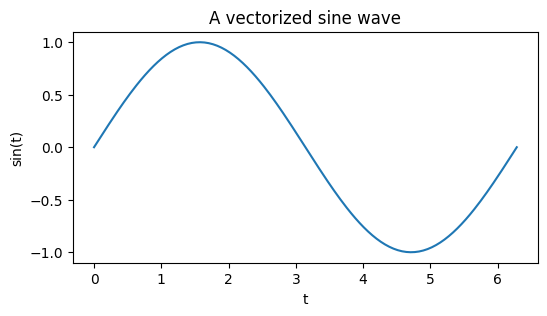

In [35]:
t = np.linspace(0, 2*np.pi, 200)
y = np.sin(t)

plt.figure(figsize=(6, 3))
plt.plot(t, y)
plt.xlabel("t")
plt.ylabel("sin(t)")
plt.title("A vectorized sine wave")
plt.show()

# 7. Reductions and the `axis` argument

A **reduction** collapses many numbers into a summary: a sum, a mean, a maximum. Applied to a
whole array, it returns a single number.

In [36]:
values = np.array([3.0, 1.0, 4.0, 1.0, 5.0])

print("sum:  ", values.sum())
print("mean: ", values.mean())
print("std:  ", values.std())
print("min:  ", values.min())
print("max:  ", values.max())
print("argmax (position of the maximum):", values.argmax())

sum:   14.0
mean:  2.8
std:   1.6
min:   1.0
max:   5.0
argmax (position of the maximum): 4


## 7.1 Reducing along one axis

For a two-dimensional array we usually do **not** want a single number. We want one number per
column, or one per row.

The `axis` argument says **which axis to collapse**. This is the part that confuses everyone, so
state it carefully:

- `axis=0` collapses the **rows**, moving *down* each column. You get one value **per column**.
- `axis=1` collapses the **columns**, moving *across* each row. You get one value **per row**.

A useful check: the axis you name is the one that *disappears* from the shape.

In [37]:
M = np.array([
    [1.0,  2.0,  3.0],
    [4.0,  5.0,  6.0],
    [7.0,  8.0,  9.0],
    [10.0, 11.0, 12.0]
])

print("M shape:", M.shape)
print()
print("M.sum()        ->", M.sum(), "  (a single number)")
print("M.sum(axis=0)  ->", M.sum(axis=0), " shape", M.sum(axis=0).shape, " one per column")
print("M.sum(axis=1)  ->", M.sum(axis=1), " shape", M.sum(axis=1).shape, " one per row")

M shape: (4, 3)

M.sum()        -> 78.0   (a single number)
M.sum(axis=0)  -> [22. 26. 30.]  shape (3,)  one per column
M.sum(axis=1)  -> [ 6. 15. 24. 33.]  shape (4,)  one per row


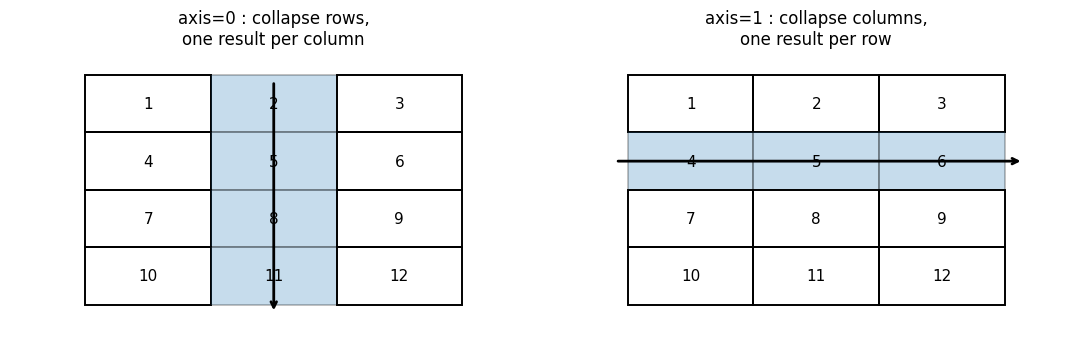

In [38]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))

for panel, axis in enumerate([0, 1]):
    a = ax[panel]
    n_rows, n_cols = M.shape
    for r in range(n_rows):
        for c in range(n_cols):
            highlight = (axis == 0 and c == 1) or (axis == 1 and r == 1)
            a.add_patch(plt.Rectangle((c, n_rows - 1 - r), 1, 1, fill=highlight,
                                      alpha=0.25 if highlight else 1,
                                      edgecolor="black", linewidth=1.4))
            a.text(c + 0.5, n_rows - 1 - r + 0.5, f"{M[r, c]:.0f}",
                   ha="center", va="center", fontsize=11)
    if axis == 0:
        a.annotate("", xy=(1.5, -0.15), xytext=(1.5, n_rows - 0.1),
                   arrowprops={"arrowstyle": "->", "linewidth": 2})
        a.set_title("axis=0 : collapse rows,\none result per column", fontsize=12)
    else:
        a.annotate("", xy=(n_cols + 0.15, n_rows - 1.5), xytext=(-0.1, n_rows - 1.5),
                   arrowprops={"arrowstyle": "->", "linewidth": 2})
        a.set_title("axis=1 : collapse columns,\none result per row", fontsize=12)
    a.set_xlim(-0.6, n_cols + 0.6)
    a.set_ylim(-0.6, n_rows + 0.4)
    a.axis("off")

plt.tight_layout()
plt.show()

In a data matrix, rows are samples and columns are features. So the reduction you almost always
want is `axis=0`: **one summary per feature, computed over all samples.**

That is exactly what we use in the normalization section below.

In [39]:
X = np.array([
    [1.0, 10.0, 100.0],
    [2.0, 20.0, 200.0],
    [3.0, 30.0, 300.0],
    [4.0, 40.0, 400.0]
])

print("mean of each feature:", X.mean(axis=0))
print("mean of each sample: ", X.mean(axis=1))

mean of each feature: [  2.5  25.  250. ]
mean of each sample:  [ 37.  74. 111. 148.]


<div class="alert alert-success">
<b>Mini-exercise 4 — Choosing an axis</b><br>
Using the matrix <code>M</code> defined above:
<br><br>
1. Compute the maximum of each column.<br>
2. Compute the mean of each row.<br>
3. Without running it, predict the <em>shape</em> of <code>M.std(axis=0)</code>, then check.<br>
4. <code>M</code> has shape <code>(4, 3)</code>. Which axis would you collapse to get 4 numbers?
</div>

In [40]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

# 8. Boolean masking

Comparing an array with a number does **not** give a single True or False. It compares every
element and returns an array of booleans, the same shape as the original. This is called a
**mask**.

In [41]:
temperatures = np.array([21.4, 25.8, 19.2, 30.1, 22.7, 18.0])

mask = temperatures > 22

print("temperatures:", temperatures)
print("mask:        ", mask)

temperatures: [21.4 25.8 19.2 30.1 22.7 18. ]
mask:         [False  True False  True  True False]


The mask becomes useful when we use it as an index. Passing a boolean array in square brackets
keeps the elements where the mask is `True` and discards the rest.

In [42]:
print("above 22:", temperatures[temperatures > 22])
print("below 20:", temperatures[temperatures < 20])

above 22: [25.8 30.1 22.7]
below 20: [19.2 18. ]


## 8.1 Combining conditions

Conditions combine with `&` (and), `|` (or) and `~` (not).

**Each condition must be wrapped in its own brackets.** This is a genuine syntax trap: `&` binds
more tightly than `>`, so without the brackets Python groups the expression wrongly and raises a
confusing error.

Note also that the Python keywords `and`, `or` and `not` do **not** work here — they try to
collapse the whole array to a single truth value. Use the symbols.

In [43]:
warm_but_not_hot = (temperatures > 20) & (temperatures < 26)

print("mask: ", warm_but_not_hot)
print("values:", temperatures[warm_but_not_hot])
print("outside that range:", temperatures[~warm_but_not_hot])

mask:  [ True  True False False  True False]
values: [21.4 25.8 22.7]
outside that range: [19.2 30.1 18. ]


## 8.2 Counting with a mask

Because `True` counts as 1 and `False` as 0, summing a mask counts how many elements satisfy the
condition — and taking its mean gives the fraction.

Two more methods on a mask are worth knowing: `.any()` asks whether *any* element passes, and
`.all()` whether they all do. Both return a single `True` or `False`.

In [44]:
print("how many above 22:  ", (temperatures > 22).sum())
print("fraction above 22:  ", (temperatures > 22).mean())
print("any above 30?       ", (temperatures > 30).any())
print("all above 15?       ", (temperatures > 15).all())

how many above 22:   3
fraction above 22:   0.5
any above 30?        True
all above 15?        True


## 8.3 Selecting rows of a data matrix

The pattern that matters most for this course: a mask built from one column, used to select whole
**rows**.

This is how a dataset gets filtered — all samples of one class, all measurements above a
threshold, all trials that passed a quality check.

In [45]:
X = np.array([
    [1.0, 10.0],
    [2.0, 20.0],
    [3.0, 30.0],
    [4.0, 40.0]
])
y = np.array([0, 1, 0, 1])          # a class label for each row

print("rows of class 1:")
print(X[y == 1])

print("\nrows whose first feature exceeds 2:")
print(X[X[:, 0] > 2])

rows of class 1:
[[ 2. 20.]
 [ 4. 40.]]

rows whose first feature exceeds 2:
[[ 3. 30.]
 [ 4. 40.]]


## 8.4 Replacing values with `np.where`

`np.where(condition, value_if_true, value_if_false)` builds a new array by choosing element by
element. It is the vectorized equivalent of an `if` inside a loop.

In [46]:
clipped = np.where(temperatures > 25, 25.0, temperatures)

print("original:", temperatures)
print("clipped: ", clipped)

original: [21.4 25.8 19.2 30.1 22.7 18. ]
clipped:  [21.4 25.  19.2 25.  22.7 18. ]


<div class="alert alert-success">
<b>Mini-exercise 5 — Filtering data</b><br>
Using <code>rainfall = np.array([0.0, 12.4, 3.1, 0.0, 25.6, 8.8, 0.0, 41.2])</code>:
<br><br>
1. Build a mask for the days with no rain, and count them.<br>
2. Select the days with more than 10 mm.<br>
3. Select the days with rain strictly between 1 and 20 mm.<br>
4. What fraction of days were dry?<br>
5. Use <code>np.where</code> to replace every zero with <code>np.nan</code>. This is how a value
is marked as <em>missing</em> rather than genuinely zero — a distinction <code>01C</code> takes up
in its section on missing values, and one that matters here, since a dry day and an unrecorded day
are not the same thing.
</div>

In [47]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

# 9. Vectorization

A vectorized operation applies an operation to a whole array at once.

This usually makes code:

- shorter;
- easier to read;
- closer to mathematical notation;
- faster for large arrays.

The speed advantage appears because NumPy performs the low-level numerical loop in compiled code, rather than in a Python `for` loop.

The check below uses `np.allclose(a, b)`, which reports whether two arrays agree to within a small
numerical tolerance. It is the right way to compare floating-point results — exact equality with
`==` is unreliable once rounding is involved.

In [48]:
# Same calculation in two styles: explicit loop and vectorized NumPy.

x = np.linspace(0, 1, 10)

# Explicit Python loop
loop_result = []
for value in x:
    loop_result.append(value**2 + 2*value + 1)
loop_result = np.array(loop_result)

# Vectorized NumPy expression
vectorized_result = x**2 + 2*x + 1

print(loop_result)
print(vectorized_result)
print("Same result?", np.allclose(loop_result, vectorized_result))

[1.         1.2345679  1.49382716 1.77777778 2.08641975 2.41975309
 2.77777778 3.16049383 3.56790123 4.        ]
[1.         1.2345679  1.49382716 1.77777778 2.08641975 2.41975309
 2.77777778 3.16049383 3.56790123 4.        ]
Same result? True


## 9.1 A timing comparison

The exact times depend on the computer, but the vectorized expression is usually much faster for
large arrays. The `%timeit` command below is a notebook feature that runs a statement repeatedly
and reports how long it takes.

In [49]:
large_x = np.linspace(0, 1, 1_000_000)

# This cell uses IPython's timing command.
# It works in Jupyter notebooks.

%timeit large_x**2 + 2*large_x + 1

729 µs ± 18.9 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [50]:
# A loop version for comparison.
# This is intentionally less efficient.

%timeit [value**2 + 2*value + 1 for value in large_x]

170 ms ± 1.81 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


Vectorization is not only about speed. It is also about expressing operations at the right level of abstraction.

For example, the following line computes a whole model prediction for many input values:

```python
y = a*x + b
```

Later, the same idea will appear when we apply models to many data points at once.

<div class="alert alert-success">
<b>Mini-exercise 6 — Vectorize a loop</b><br>
The next cell computes <code>y = sin(x) + x²</code> using a loop. Rewrite it as one vectorized
NumPy expression, then check your answer with <code>np.allclose</code>.
</div>

In [51]:
x = np.linspace(-2, 2, 20)

y_loop = []
for value in x:
    y_loop.append(np.sin(value) + value**2)
y_loop = np.array(y_loop)

print(y_loop)

[ 3.09070257  2.22603083  1.49310801  0.89298426  0.42475986  0.08562498
 -0.12901626 -0.22534284 -0.21084401 -0.09398854  0.11614921  0.41029
  0.77935946  1.21488884  1.70938887  2.25668058  2.8521681   3.49304157
  4.1784013   4.90929743]


In [52]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

# 10. Broadcasting

In mathematics, adding a scalar to a vector is not a standard vector-space operation.

For example, if

```python
x = np.array([10, 20, 30])
```

then the expression

```python
x + 5
```

does not mean vector addition in the usual mathematical sense, because `5` is not a vector.

However, in scientific programming this operation is extremely useful. NumPy interprets it as:

```python
np.array([10, 20, 30]) + np.array([5, 5, 5])
```

The scalar is virtually expanded to match the shape of the array. This mechanism is called **broadcasting**.

Broadcasting lets us write compact code without explicitly creating repeated arrays.

Two common examples are:

1. adding a constant offset to all measurements;
2. centering or scaling all data points using a mean or standard deviation.

For example, if a temperature sensor is known to be biased by `-0.4` degrees, we can correct all measurements with one operation.

In [53]:
temperatures = np.array([21.4, 22.1, 20.9, 23.0])
correction = 0.4

temperatures + correction

array([21.8, 22.5, 21.3, 23.4])

Similarly, if we want to center data by subtracting its mean, broadcasting allows us to subtract a single number from all elements.

In [54]:
x = np.array([10, 20, 30, 40])

x - x.mean()

array([-15.,  -5.,   5.,  15.])

## 10.1 A scalar over a one-dimensional array

The scalar is not really copied in memory many times. Conceptually, however, it is helpful to
imagine that NumPy expands it to match the array, as in the diagram below.

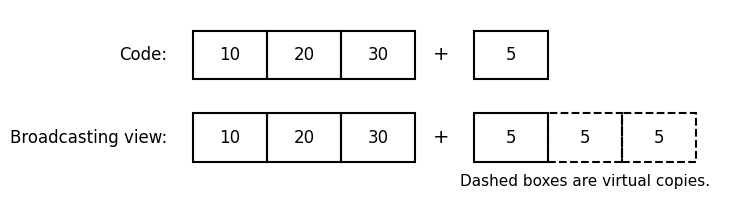

In [55]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

def row(values, x, y, dashed_from=len([10, 20, 30])):
    for i, v in enumerate(values):
        ls = "--" if i >= dashed_from else "-"
        ax.add_patch(Rectangle((x+i, y), 1, .7, fill=False, lw=1.5, ls=ls))
        ax.text(x+i+.5, y+.35, str(v), ha="center", va="center", fontsize=12)

fig, ax = plt.subplots(figsize=(8.5, 2.6))

row([10, 20, 30], 0, 1.2)
row([5], 3.8, 1.2, dashed_from=1)
row([10, 20, 30], 0, 0)
row([5, 5, 5], 3.8, 0, dashed_from=1)

for y, label in [(1.55, "Code:"), (0.35, "Broadcasting view:")]:
    ax.text(-.35, y, label, ha="right", va="center", fontsize=12)
    ax.text(3.35, y, "+", ha="center", va="center", fontsize=14)

ax.text(5.3, -.35, "Dashed boxes are virtual copies.", ha="center", fontsize=11)

ax.set(xlim=(-1.7, 7.2), ylim=(-.7, 2.2))
ax.axis("off")
plt.show()

In [56]:
x = np.array([10, 20, 30])

x + 5

array([15, 25, 35])

## 10.2 A row vector over a matrix

Many students find the following operation surprising:

```python
X.shape        # (3, 4)
offsets.shape  # (4,)
```

Why does `X + offsets` work?

Recall from section 5 that `(4,)` is a one-dimensional array of length 4, with no row or column
orientation.

A useful simplified interpretation is:

- `(3,4)` means a matrix with 4 columns;
- `(4,)` means a sequence of 4 values;
- when broadcasting, NumPy lines the vector up with the **last** index of the matrix — for a
  two-dimensional array that is the column index, the second of the two in `A[row, column]`.

This is why `(3,4)` is compatible with `(4,)`: the 4 matches the number of columns. A `(4,3)`
matrix would *not* be compatible with `(4,)`, because its last index runs over 3 columns, not 4.

The full rule behind this is in the appendix, section 10.4. It is not needed in order to follow
the class, but it is the place to go the first time this feels like a rule you are memorising
rather than understanding.

In [57]:
X = np.array([
    [10, 20, 30, 40],
    [11, 21, 31, 41],
    [12, 22, 32, 42]
])

offsets = np.array([100, 200, 300, 400])

X + offsets

array([[110, 220, 330, 440],
       [111, 221, 331, 441],
       [112, 222, 332, 442]])

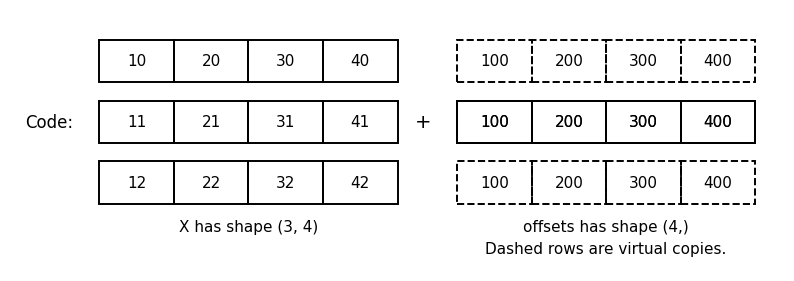

In [58]:
fig, ax = plt.subplots(figsize=(10, 3.4))

X = np.array([[10, 20, 30, 40],
              [11, 21, 31, 41],
              [12, 22, 32, 42]])
offsets = np.array([100, 200, 300, 400])

def grid(A, x0, y0, dashed_rows=()):
    for r in range(A.shape[0]):
        for c in range(A.shape[1]):
            ls = "--" if r in dashed_rows else "-"
            ax.add_patch(Rectangle((x0+c, y0-r), 1, .7, fill=False, lw=1.4, ls=ls))
            ax.text(x0+c+.5, y0-r+.35, str(A[r, c]), ha="center", va="center", fontsize=11)

grid(X, 0, 2)
ax.text(4.35, 1.35, "+", ha="center", va="center", fontsize=14)

grid(offsets[None, :], 4.8, 1)
grid(np.tile(offsets, (3, 1)), 4.8, 2, dashed_rows=(0, 2))

ax.text(-.35, 1.35, "Code:", ha="right", va="center", fontsize=12)
ax.text(2, -.45, "X has shape (3, 4)", ha="center", fontsize=11)
ax.text(6.8, -.45, "offsets has shape (4,)", ha="center", fontsize=11)
ax.text(6.8, -.8, "Dashed rows are virtual copies.", ha="center", fontsize=11)

ax.set(xlim=(-1.2, 9.2), ylim=(-1.1, 3.2))
ax.axis("off")
plt.show()

This pattern appears constantly in machine learning. For example, if each column is a feature, we may subtract a different mean from each column.

In [59]:
feature_means = X.mean(axis=0)

X - feature_means

array([[-1., -1., -1., -1.],
       [ 0.,  0.,  0.,  0.],
       [ 1.,  1.,  1.,  1.]])

## 10.3 A column vector over a matrix

Sometimes we want a different value for each row instead.

To do that, we need a column-shaped array with shape `(3, 1)`, not a one-dimensional array with shape `(3,)`.

This is where shape manipulation becomes important.

In [60]:
row_offsets = np.array([[1000], [2000], [3000]])

X + row_offsets

array([[1010, 1020, 1030, 1040],
       [2011, 2021, 2031, 2041],
       [3012, 3022, 3032, 3042]])

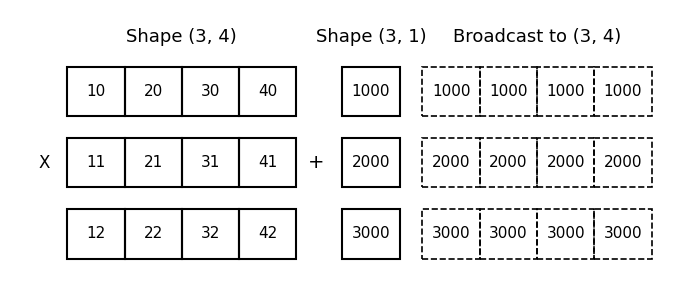

In [61]:
fig, ax = plt.subplots(figsize=(8.5, 3.6))

matrix = np.array([
    [10, 20, 30, 40],
    [11, 21, 31, 41],
    [12, 22, 32, 42]
])
row_offsets = np.array([[1000], [2000], [3000]])

for r in range(matrix.shape[0]):
    for c in range(matrix.shape[1]):
        ax.add_patch(Rectangle((c, 2 - r), 1, 0.7, fill=False, linewidth=1.5))
        ax.text(c + 0.5, 2 - r + 0.35, str(matrix[r, c]), ha="center", va="center", fontsize=11)

ax.text(-0.3, 1.35, "X", ha="right", va="center", fontsize=12)
ax.text(4.35, 1.35, "+", ha="center", va="center", fontsize=14)

for r, value in enumerate(row_offsets[:, 0]):
    ax.add_patch(Rectangle((4.8, 2 - r), 1, 0.7, fill=False, linewidth=1.5))
    ax.text(5.3, 2 - r + 0.35, str(value), ha="center", va="center", fontsize=11)

for r, value in enumerate(row_offsets[:, 0]):
    for c in range(matrix.shape[1]):
        ax.add_patch(Rectangle((6.2 + c, 2 - r), 1, 0.7, fill=False, linestyle="--", linewidth=1.2))
        ax.text(6.2 + c + 0.5, 2 - r + 0.35, str(value), ha="center", va="center", fontsize=11)

ax.text(2.0, 3.05, "Shape (3, 4)", ha="center", fontsize=13)
ax.text(5.3, 3.05, "Shape (3, 1)", ha="center", fontsize=13)
ax.text(8.2, 3.05, "Broadcast to (3, 4)", ha="center", fontsize=13)

ax.set_xlim(-1.0, 10.5)
ax.set_ylim(-0.4, 3.5)
ax.axis("off")

plt.show()

In [62]:
x = np.array([1000, 2000, 3000])

x.shape

(3,)

In [63]:
x[:, None].shape

(3, 1)

In [64]:
X + x[:, None]

array([[1010, 1020, 1030, 1040],
       [2011, 2021, 2031, 2041],
       [3012, 3022, 3032, 3042]])

Broadcasting is very useful, but it can also hide mistakes. When an operation gives an unexpected result, inspect the shapes first.

In [65]:
X.shape, offsets.shape, row_offsets.shape

((3, 4), (4,), (3, 1))

## 10.4 Technical appendix: broadcasting and shape alignment

The explanation used in class is intentionally simplified. For practical programming, it is often sufficient to think in terms of matching rows, columns and dimensions.

This appendix describes the actual broadcasting algorithm used by NumPy.

### One-dimensional arrays are special

Suppose we have two arrays with these shapes:

```python
X.shape        # (3, 4)
offsets.shape  # (4,)
```

Many students expect `X + offsets` either to raise an error, or to read `(4,)` as a column vector
and add the offsets down the columns rather than across the rows.

Neither happens.

A one-dimensional NumPy array has **no row or column orientation** — the point made in section 5,
and the reason `(4,)` is written with a comma. It is a length, rather than as a row or column vector.

In contrast:

```python
np.array([[1,2,3,4]]).shape
```

gives

```python
(1,4)
```

while

```python
np.array([[1],[2],[3],[4]]).shape
```

gives

```python
(4,1)
```

These three shapes are fundamentally different.

### The broadcasting algorithm

When NumPy combines two arrays, it compares their shapes from **right to left**.

If one shape has fewer dimensions, NumPy conceptually pads it on the left with dimensions of size 1.

For example:

```text
(3,4)
(4,)
```

becomes

```text
(3,4)
(1,4)
```

The dimensions are then compared pairwise.

Two dimensions are compatible if:

1. they are equal;
2. one of them is 1.

Thus:

```text
3 vs 1  -> compatible
4 vs 4  -> compatible
```

and broadcasting succeeds.

The resulting shape is:

```text
(3,4)
```

### Why right-to-left alignment?

At first sight, left-to-right alignment may appear more natural.

However, right alignment makes operations on higher-dimensional arrays much more convenient.

Consider RGB images stored as:

```python
images.shape
```

```text
(1000, 64, 64, 3)
```

Suppose we want to add one offset to each color channel:

```python
offsets.shape
```

```text
(3,)
```

NumPy aligns the shapes as

```text
(1000,64,64,3)
(            3)
```

which becomes

```text
(1000,64,64,3)
(1,1,1,3)
```

The three values are then reused for every image and every pixel.

This is one of the main reasons why broadcasting is so powerful in scientific computing and deep learning.

### Broadcasting does not copy data

The figures shown earlier may give the impression that NumPy literally creates many copies of an array.

Conceptually this is a useful way to think about broadcasting, but it is not what actually happens.

For example:

```python
x = np.array([10,20,30])
x + 5
```

can be interpreted as

```python
[10,20,30] + [5,5,5]
```

but NumPy does not allocate memory for the expanded array `[5,5,5]`.

Instead it performs the operation as if the array had been expanded.

This is one reason why broadcasting is both elegant and efficient.

### Examples

Compatible:

```text
(3,4) and (4,)
(3,4) and (1,4)
(3,4) and (3,1)
(10,64,64,3) and (3,)
(100,50,20) and (20,)
```

Not compatible:

```text
(3,4) and (3,)
(3,4) and (2,4)
(3,4) and (5,)
```

### Practical advice

When a broadcasting operation produces an unexpected result:

1. Print the shapes of all arrays.
2. Align the shapes on the right.
3. Pad missing dimensions with 1.
4. Check compatibility dimension by dimension.

Most broadcasting bugs can be diagnosed by understanding array shapes rather than the operation itself.

# 11. Broadcasting for data normalization

A common preprocessing step is to standardize each feature:

```text
standardized value = (value - feature mean) / feature standard deviation
```

For a data matrix, we usually compute one mean and one standard deviation per column.

In [66]:
X = np.array([
    [1.0, 10.0, 100.0],
    [2.0, 20.0, 200.0],
    [3.0, 30.0, 300.0],
    [4.0, 40.0, 400.0]
])

feature_mean = X.mean(axis=0)
feature_std = X.std(axis=0)

print("X shape:", X.shape)
print("feature_mean:", feature_mean)
print("feature_mean shape:", feature_mean.shape)
print("feature_std:", feature_std)
print("feature_std shape:", feature_std.shape)

X shape: (4, 3)
feature_mean: [  2.5  25.  250. ]
feature_mean shape: (3,)
feature_std: [  1.11803399  11.18033989 111.80339887]
feature_std shape: (3,)


In [67]:
X_standardized = (X - feature_mean) / feature_std

print(X_standardized)
print("Column means after standardization:", X_standardized.mean(axis=0))
print("Column stds after standardization:", X_standardized.std(axis=0))

[[-1.34164079 -1.34164079 -1.34164079]
 [-0.4472136  -0.4472136  -0.4472136 ]
 [ 0.4472136   0.4472136   0.4472136 ]
 [ 1.34164079  1.34164079  1.34164079]]
Column means after standardization: [0. 0. 0.]
Column stds after standardization: [1. 1. 1.]


The expression

```python
(X - feature_mean) / feature_std
```

works because `feature_mean` and `feature_std` have shape `(3,)`, so they are broadcast across the rows of `X`.

<div class="alert alert-success">
<b>Mini-exercise 7 — Manual standardization</b><br>
Create a matrix with 5 rows and 2 columns. Compute the column means and standard deviations. Then
standardize the matrix using broadcasting. Check that the standardized columns have mean
approximately 0 and standard deviation approximately 1.
</div>

In [68]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

# 12. Random numbers

Synthetic data, shuffled datasets, initial weights of a neural network and train/test splits all
need random numbers. NumPy's modern interface starts by creating a **generator**.

The number passed to `default_rng` is the **seed**. Given the same seed, the generator produces
exactly the same sequence every time — which is what makes an experiment reproducible.

In [69]:
rng = np.random.default_rng(42)

print("uniform in [0, 1):", rng.random(4))
print("normal, mean 0 sd 1:", rng.normal(0, 1, 4))
print("integers 0-9:", rng.integers(0, 10, 6))

uniform in [0, 1): [0.77395605 0.43887844 0.85859792 0.69736803]
normal, mean 0 sd 1: [-1.95103519 -1.30217951  0.1278404  -0.31624259]
integers 0-9: [5 1 8 4 5 3]


Each **call** advances the generator, which is why the three lines above draw different numbers
rather than repeating the same ones. Re-running the whole cell is a different matter: it starts by
re-creating the generator from the same seed, so the output repeats exactly. Try it.

Re-creating the generator with the same seed rewinds it.

In [70]:
first = np.random.default_rng(42).normal(size=5)
again = np.random.default_rng(42).normal(size=5)
other = np.random.default_rng(7).normal(size=5)

print("seed 42:", first)
print("seed 42:", again, "  <- identical")
print("seed  7:", other, "  <- different")

seed 42: [ 0.30471708 -1.03998411  0.7504512   0.94056472 -1.95103519]
seed 42: [ 0.30471708 -1.03998411  0.7504512   0.94056472 -1.95103519]   <- identical
seed  7: [ 0.00123015  0.29874554 -0.27413786 -0.89059184 -0.45467079]   <- different


> Set a seed in any notebook whose results you intend to report or compare. Without one, your
> numbers change on every run and nobody, including you, can reproduce them.

Two more operations we will use repeatedly:

In [71]:
rng = np.random.default_rng(0)

data = np.arange(10)
print("shuffled sample of 5:", rng.choice(data, size=5, replace=False))

deck = np.arange(6)
rng.shuffle(deck)               # shuffles in place
print("shuffled in place:   ", deck)

shuffled sample of 5: [4 7 2 3 5]
shuffled in place:    [5 2 4 3 1 0]


# 13. A small scientific example

Suppose we measure a signal at several time points for several experimental conditions.

We can store the signal as a matrix:

- rows = time points;
- columns = experimental conditions.

In [72]:
time = np.linspace(0, 10, 200)
rates = np.array([0.2, 0.5, 1.0])

# time has shape (200,)
# rates has shape (3,)
# We reshape time to (200, 1), so broadcasting produces a (200, 3) matrix.

signals = np.exp(-time.reshape(200, 1) * rates)

print("time shape:", time.shape)
print("rates shape:", rates.shape)
print("signals shape:", signals.shape)

time shape: (200,)
rates shape: (3,)
signals shape: (200, 3)


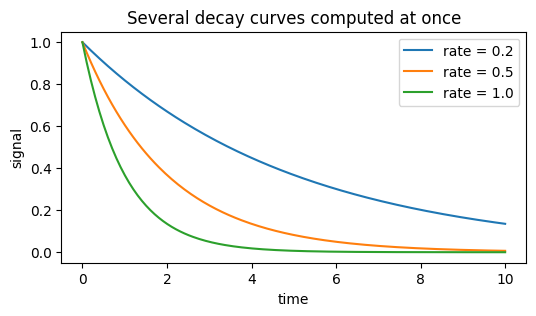

In [73]:
plt.figure(figsize=(6, 3))
plt.plot(time, signals)
plt.xlabel("time")
plt.ylabel("signal")
plt.title("Several decay curves computed at once")
plt.legend([f"rate = {r}" for r in rates])
plt.show()

Without broadcasting, we would need to compute the three curves separately or write an explicit loop. Broadcasting lets us express the whole calculation in one array expression.

<div class="alert alert-success">
<b>Mini-exercise 8 — Gaussian curves</b><br>
Use broadcasting to create several Gaussian curves at once. Let <code>x</code> contain 300 points
between -5 and 5, and let <code>centers</code> be an array containing <code>-2</code>,
<code>0</code>, and <code>2</code>. Compute <code>Y = exp(-(x - center)²)</code> for all centers at
once, so that <code>Y</code> has shape <code>(300, 3)</code>. Plot the three curves.
</div>

In [74]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

# 14. Common mistakes

## Mistake 1: forgetting that lists are not arrays

```python
[1, 2, 3] + [10, 20, 30]
```

This concatenates two lists. It does not add element by element.

## Mistake 2: ignoring shapes

Many NumPy errors are shape errors. Print `.shape` often.

## Mistake 3: confusing `(n,)` and `(n, 1)`

A one-dimensional array is not the same as a column vector.

## Mistake 4: assuming a slice is a copy

Slicing an array gives a **view**. Writing into it changes the original. Use `.copy()` when you
need independence.

## Mistake 5: reducing along the wrong axis

`axis=0` gives one value per column; `axis=1` gives one per row. Check the shape of the result.

## Mistake 6: using `and` / `or` with masks

Use `&`, `|` and `~`, and bracket each condition.

## Mistake 7: vectorizing too early

For a difficult problem, it is often reasonable to first write a simple loop, check correctness,
and only then vectorize.

# 15. Final exercises

<div class="alert alert-success">
<b>Exercise 1 — Pairwise distances</b><br>
Given the one-dimensional positions
<br><br>
<code>positions = np.array([0.0, 1.5, 2.0, 5.0])</code>
<br><br>
construct a 4 by 4 matrix whose entry <code>(i, j)</code> is the distance between position
<code>i</code> and position <code>j</code>.
<br><br>
Hint: reshape one copy of <code>positions</code> as a column and use broadcasting.
</div>

In [75]:
positions = np.array([0.0, 1.5, 2.0, 5.0])

In [76]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

<div class="alert alert-success">
<b>Exercise 2 — Feature scaling for a synthetic dataset</b><br>
The next cell creates a synthetic dataset with three features on very different scales.
<br><br>
1. Inspect the shape of the dataset.<br>
2. Compute the mean and standard deviation of each feature.<br>
3. Standardize the dataset using broadcasting.<br>
4. Verify the result.<br>
5. How many samples have a standardized first feature greater than 1? Use a boolean mask.
</div>

In [77]:
rng = np.random.default_rng(42)

X = np.column_stack([
    rng.normal(loc=0, scale=1, size=100),
    rng.normal(loc=100, scale=20, size=100),
    rng.normal(loc=1_000_000, scale=50_000, size=100)
])

X.shape

(100, 3)

In [78]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

<div class="alert alert-success">
<b>Exercise 3 — From formula to vectorized code</b><br>
The logistic function is
<br><br>
<code>f(x) = 1 / (1 + exp(-x))</code>
<br><br>
1. Create an array of 200 values from -8 to 8.<br>
2. Compute the logistic function for all values using one vectorized expression.<br>
3. Plot the result.<br>
4. What is the approximate value of the function at <code>x = 0</code>?<br>
5. For how many of your 200 points does the function exceed 0.9?
</div>

In [79]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

# Key Takeaways

- NumPy arrays are the basic objects for numerical computing in Python. They hold one `dtype`.
- Always inspect array shapes. Most NumPy bugs are shape bugs.
- Slicing gives a **view**, not a copy: writing into a slice changes the original. Use `.copy()`.
- NumPy operations are element-wise unless a specific matrix operation is requested.
- Reductions collapse the axis you name: `axis=0` gives one value per column, `axis=1` one per row.
- A comparison gives a **boolean mask**, which can be used to select, count and filter.
- Vectorized code is usually clearer and faster than explicit Python loops.
- Broadcasting allows arrays with compatible shapes to interact without copying data.
- Seed your random generator whenever results need to be reproducible.

# Optional preparation for the next notebook

Before the next session, students should be comfortable with:

- creating and slicing NumPy arrays;
- telling a view from a copy;
- using `axis=0` and `axis=1` in reductions;
- selecting data with a boolean mask;
- reading shape errors;
- standardizing a feature matrix.

Notebook `01C` moves from arrays to **tabular data**, using pandas. The ideas are the same — rows
are samples, columns are features — but the columns acquire names.